In [1]:
from collections import defaultdict
import os
import random
import numpy as np
import pandas as pd
import json
import pickle
import gzip
from tqdm import tqdm
import scipy.sparse as sp


def load_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)


def save_pickle(data, filename):
    with open(filename, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def ReadLineFromFile(path):
    lines = []
    with open(path,'r') as fd:
        for line in fd:
            lines.append(line.rstrip('\n'))
    return lines

def parse(path):
    g = gzip.open(path, 'r')
    for l in g:
        # l = l.replace('false', 'False').replace('true', 'True')
        # Convert bytes to string
        data_str = l.decode('utf-8')
        # Replace 'false' with 'False' and 'true' with 'True'
        data_str = data_str.replace('false', 'False').replace('true', 'True')

        # Parse the JSON string into a dictionary
        yield eval(data_str)
'''
Set seeds
'''
seed = 999
random.seed(seed)
np.random.seed(seed)

/home/sairamv/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
short_data_name = 'sports'

# Create Splits for Review

In [3]:
datamaps = load_json("data/{}/datamaps.json".format(short_data_name))
print(datamaps.keys())

dict_keys(['user2id', 'item2id', 'id2user', 'id2item', 'attribute2id', 'id2attribute', 'attributeid2num'])


In [4]:
exp_data = load_pickle("data/{}/exp_splits.pkl".format(short_data_name))
exp_data.keys()

dict_keys(['train', 'val', 'test'])

In [5]:
rev_data = load_pickle("data/{}/review_splits.pkl".format(short_data_name))
rev_data.keys()

dict_keys(['train', 'val', 'test', 'train_indices', 'val_indices', 'test_indices'])

In [6]:
meta_data = []
for meta in parse(os.path.join("data", short_data_name, 'meta.json.gz')):
    meta_data.append(meta)
meta_dict = {}
for i, meta_item in enumerate(meta_data):
    meta_dict[meta_item['asin']] = i

In [7]:
rev_data['train'][0]

{'reviewerID': 'AIXZKN4ACSKI',
 'asin': '1881509818',
 'reviewerName': 'David Briner',
 'helpful': [0, 0],
 'reviewText': 'This came in on time and I am veru happy with it, I haved used it already and it makes taking out the pins in my glock 32 very easy',
 'overall': 5.0,
 'summary': 'Woks very good',
 'unixReviewTime': 1390694400,
 'reviewTime': '01 26, 2014',
 'explanation': 'This came in on time and I am veru happy with it',
 'feature': 'cam'}

In [8]:
len(rev_data['train_indices']) + len(rev_data['val_indices']) + len(rev_data['test_indices'])

296337

In [9]:
len(exp_data['train']) + len(exp_data['test']) + len(exp_data['val'])

196804

In [10]:
seq_data = ReadLineFromFile(f"data/{short_data_name}/sequential_data.txt")
len(seq_data)

35598

In [11]:
sum([len(x.split()) - 1 for x in seq_data])

296337

In [12]:
users, items = len(datamaps['user2id']), len(datamaps['item2id'])
count = len(rev_data['train']) + len(rev_data['test']) + len(rev_data['val'])
print("# Users: ",users)
print("# Items: ",items)
print("# Reviews: ",count)
print("Sparsity: ",count * 100.0 / (users * items),'%')

# Users:  35598
# Items:  18357
# Reviews:  296337
Sparsity:  0.045348045456958995 %


In [13]:
counts = {float(r): 0 for r in range(1,6)}
for record in rev_data['train']:
    counts[record['overall']] += 1
T = sum(counts.values())
print(T)
for k,c in counts.items():
    counts[k] = float(counts[k])/T
print(counts)

237070
{1.0: 0.031113173324334584, 2.0: 0.03427679588307251, 3.0: 0.08103513730121904, 4.0: 0.21883409963301978, 5.0: 0.634740793858354}


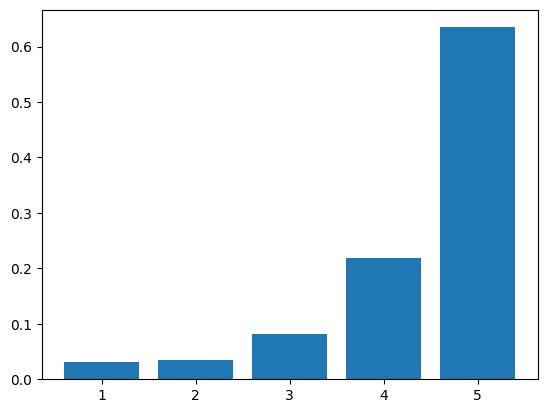

In [14]:
import matplotlib.pyplot as plt
X = [float(r) for r in range(1,6)]
plt.bar(X, [counts[x] for x in X])
plt.show()